<a href="https://colab.research.google.com/github/PCeltide/Algorithms-in-Machine-Learning-and-Their-Application/blob/main/Assignments/Assignment%203/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis

In this exercise sheet we look into how to compute and apply a Principal Component Analysis (PCA).

In [2]:
import os

print("Cloning repository...")
!git clone https://github.com/PCeltide/Algorithms-in-Machine-Learning-and-Their-Application.git

repo_name = 'Algorithms-in-Machine-Learning-and-Their-Application'
source_folder = f'/content/{repo_name}/Assignments/Assignment 3'
destination_folder = '/content/'

print("\nMoving project files to the main directory...")
!mv /content/Algorithms-in-Machine-Learning-and-Their-Application/Assignments/Assignment\ 3/* {destination_folder}

print("\nVerifying contents of the main /content/ directory:")
!ls -l {destination_folder}

data_file_path = os.path.join(destination_folder, 'data', 'pca_ped_25x50.mat')
if os.path.exists(data_file_path):
    print(f"\nSuccess! Found the data file at: {data_file_path}")
else:
    print("\nError: Could not find the data file after moving.")

Cloning repository...
Cloning into 'Algorithms-in-Machine-Learning-and-Their-Application'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 142 (delta 23), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 14.76 MiB | 5.58 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Encountered 1 file(s) that should have been pointers, but weren't:
	Assignments/Assignment 3/mllab/pca/hog_ref.mat

Moving project files to the main directory...

Verifying contents of the main /content/ directory:
total 28
drwxr-xr-x 4 root root 4096 Jun 21 07:21  Algorithms-in-Machine-Learning-and-Their-Application
drwxr-xr-x 2 root root 4096 Jun 21 07:21  data
-rw-r--r-- 1 root root 4005 Jun 21 07:21  factor_split.py
drwxr-xr-x 2 root root 4096 Jun 21 07:21  hog
drwxr-xr-x 3 root root 4096 Jun 21 07:21  mllab
drwxr-xr-x 2 root root 4096 Jun 21 07:21 'sample data'
drwxr-xr-x 1 root r

## Toy 4D Example

We start by loading our toy example. The data is stored as a Numpy array, it is a $2585\times 5$ matrix. The last component of each row is the label, the first four components are the coordinates in 4D. Each label is an integer from  $\{0, 1, 2, 3, 4\}$.

The data contains a noisy 2D plane which is embded into 4D. We would like to represent the data in its _intrinsic_ 2D form.

In [7]:
!pip install pillow  # install the Python package "pillow"
import numpy as np
import mllab.pca

In [ ]:
pca_toy_4d = np.load("data/pca_toy_4d.npy")
y = pca_toy_4d[:, -1]  # labels
x = pca_toy_4d[:, :-1]  # 4D coordinates


Let us plot slices from this 4D data. We provide a helper function for this:

In [ ]:
# Show documentation
mllab.pca.plot_toy_slice?

We want to remove the noise and recover the 2D information.

### Task 3.1

Write an implementation of the function below. Use a singular value decomposition (SVD), but avoid computing it completely since we only need the first $q$ eigenvectors. Remember to sort the eigenvalues accordingly. You can use a NumPy/SciPy function for this. Note: It might not return ordered eigenvalues.

In [ ]:
from scipy.sparse.linalg import svds

def pca(x, q):
    """
    Compute principal components and the coordinates.

    Parameters
    ----------

    x: (n, d) NumPy array
    q: int
       The number of principal components to compute.
       Has to be less than `p`.

    Returns
    -------

    Vq: (d, q) NumPy array, orthonormal vectors (column-wise)
    xq: (n, q) NumPy array, coordinates for x (row-wise)
    """
    if q > x.shape[1]:
      print("q needs to be smaller than the length of the data")
    mu = x.mean(axis = 0)
    X = x - mu
    _ ,_ , V = svds(X, k=q, which='LM')
    V = V[::-1, :] # Reverse the rows to make them in descending order
    V_q = V.T
    x_q = X @ V_q
    return V_q, x_q

Now we can compute the 2D dimensional representation of `x` using PCA.

In [ ]:
V, xq = pca(x, q=2)

### Task 3.2 a

And then plot the coordinates `xq`, which are two dimensional. We provide a helper function for this task. Let us check how to use it:

In [ ]:
mllab.pca.plot_toy_2d?

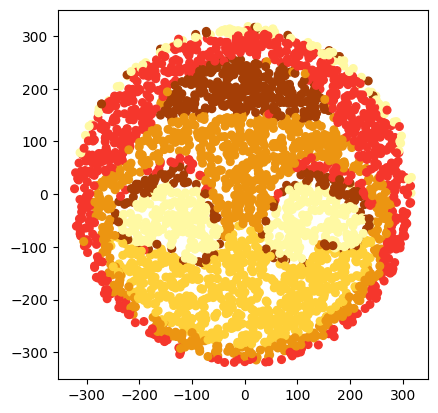

In [ ]:
temp = mllab.pca.plot_toy_2d(xq, y)

Hopefully you appreciate the result.

### Task 3.2 b

Let us see how PCA handles a non-linear transformation. To test this we map our data into 3D by keeping the y-axis as the new z-axis and bending x-coordinate onto an ellipse.

In [ ]:
mllab.pca.map_on_ellipse?

In [ ]:
xyz = mllab.pca.map_on_ellipse(xq, a=32, b=1, gap_angle=90)

In [ ]:
!pip install --upgrade matplotlib ipympl ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

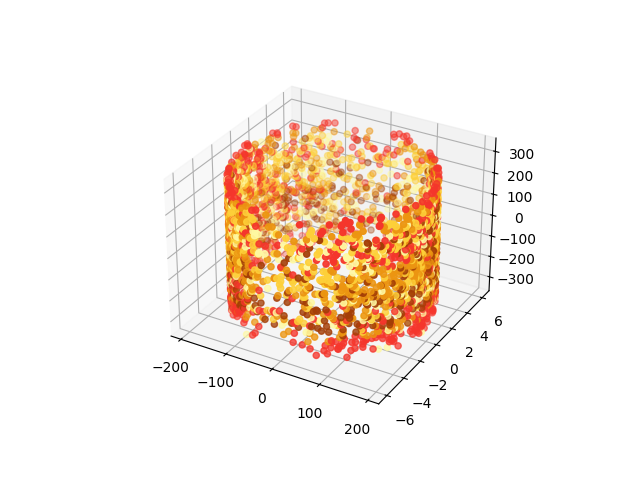

In [ ]:
%matplotlib widget
mllab.pca.plot_toy_3d(xyz, y)

**(Remeber to stop the interactive plot by pressing the shutdown icon!)**

Now apply PCA to our transformed data and plot the result as before.

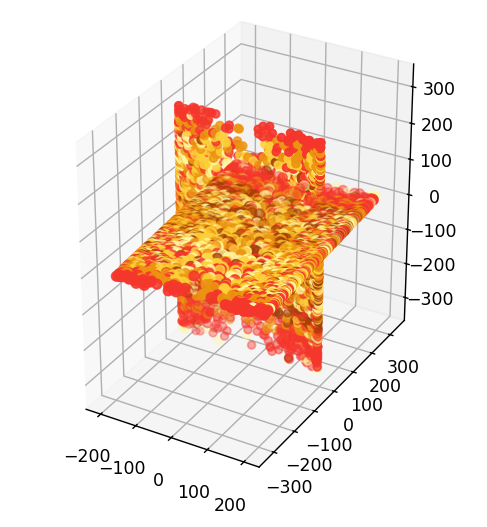

In [ ]:
%matplotlib inline
V, xq = pca(xyz, q=2)

temp = mllab.pca.plot_toy_2d(xq, y)

Could be worse, but undeniably discomforting. Try different axes lengths and gap sizes of the ellipse, especially try increasing b. What do you observe?

### Task 3.3 a

We want to see if PCA can improve the accuracy of separating hyperlanes. First compute the singular values of the Iris dataset, then check how many percent of the variance the first two principal components capture.

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
iris_x = iris['data']
iris_y = iris['target']

In [ ]:
_, sing_vals, _ = np.linalg.svd(iris_x,)
sing_vals

array([95.95991387, 17.76103366,  3.46093093,  1.88482631])

In [ ]:
def var_exp(component_numbers, singular_values):
    return singular_values[[int(x) for x in (component_numbers-1).tolist()]].sum()/singular_values.sum()

print(f"The Variance (%) explained by only the first component is {var_exp(np.ones(1), sing_vals)*100:.4}")
print(f"The Variance (%) explained by the first AND second component is {var_exp(np.array([1,2]), sing_vals)*100:.4}")

The Variance (%) explained by only the first component is 80.59
The Variance (%) explained by the first AND second component is 95.51


### Task 3.3 b

Now apply PCA and compute the first two principal components. Plot the projected 2D data in a scatter plot such that the three labels are recognizable. What do you observe?

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_1d_iris(a, b, c):
    """Show a 1D plot of three 1D datasets a, b and c.

    Top to bottom plotted in order is a, b, c."""
    af = a.flatten()
    bf = b.flatten()
    cf = c.flatten()
    left = min(x.min() for x in (af, bf, cf))
    right = max(x.max() for x in (af, bf, cf))
    for i, (x, cf) in enumerate(((af, 'red'), (bf, 'blue'), (cf, 'green'))):
        plt.hlines(i * .3, left, right, linestyles='dotted', colors=[(.8,.8,.8,1)])
        plt.eventplot(x, colors=cf, linewidths=.5, linelengths=.25, lineoffsets=(2 - i) * .3 )
    plt.axis('off')

In [ ]:
Vq_iris, xq_iris = pca(iris_x, q=2)

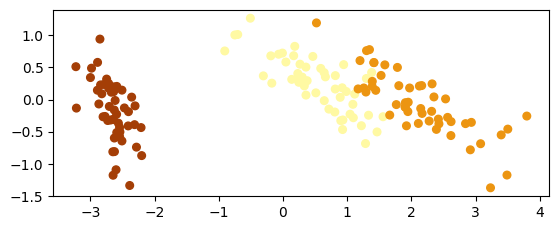

In [ ]:
plt.figure()
temp = mllab.pca.plot_toy_2d(xq_iris, iris_y)

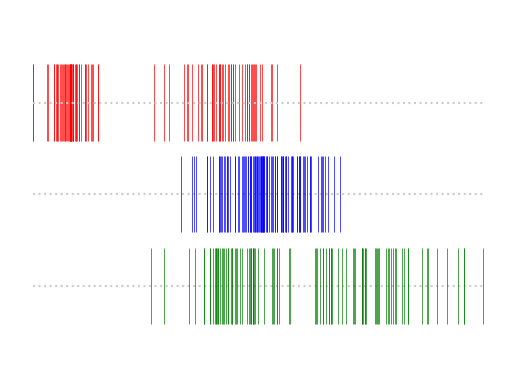

In [ ]:
xq_iris_1 = xq_iris[iris_y == 0]
xq_iris_2 = xq_iris[iris_y == 1]
xq_iris_3 = xq_iris[iris_y == 2]

plt.figure()
plot_1d_iris(xq_iris_1, xq_iris_2, xq_iris_3)

### Task 3.3 c

Finally, recompute the accurancy as in sheet 1 and compare the results. Remember to separate the data into train and test set.

In [35]:
from numpy.linalg import lstsq
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import LinearSVC

def labels(x1, x2):
    return np.concatenate((np.zeros(x1.shape[0], dtype='int'), np.ones(x2.shape[0], dtype='int')))

In [ ]:
# Add this diagnostic code before your function call
print(f"Shape of iris_x: {iris_x.shape}")
print(f"Shape of iris_y: {iris_y.shape}")

Shape of iris_x: (150, 4)
Shape of iris_y: (150,)


In [ ]:
# Let's split up the Iris data, such that each class appears equally in the test
from sklearn.model_selection import train_test_split

iris_x_train, iris_x_test, iris_y_train, iris_y_test = train_test_split(
    iris_x, iris_y,
    test_size=0.3,
    stratify=iris_y)

In [26]:
def SVM_classifier(data, classification, test_data, test_classification):
    model = LinearSVC(C=0.01, max_iter=5000)
    model.fit(data, classification)
    prediction = model.predict(test_data)
    conf_mat = confusion_matrix(test_classification, prediction)
    acc = accuracy_score(test_classification, prediction)
    return conf_mat, acc

In [ ]:
conf_mat, acc = SVM_classifier(iris_x_train, iris_y_train, iris_x_test, iris_y_test)
print(f"The confusion matrix for 4d data is:")
print(conf_mat)
print(f"Accuracy: {acc}")

<class 'numpy.ndarray'>
The confusion matrix for 4d data is:
[[15  0  0]
 [ 0  2 13]
 [ 0  0 15]]
Accuracy: 0.7111111111111111


In [ ]:
Vq, xq_iris_train = pca(iris_x_train, q=2)

# We need to transform our data using our training Vq
centered_iris_x_test = iris_x_test - iris_x_train.mean(axis=0)
xq_iris_test = centered_iris_x_test @ Vq

conf_mat, acc = SVM_classifier(xq_iris_train, iris_y_train, xq_iris_test, iris_y_test)
print(f"The confusion matrix for 4d data is:")
print(conf_mat)
print(f"Accuracy: {acc}")

<class 'numpy.ndarray'>
The confusion matrix for 4d data is:
[[15  0  0]
 [ 0  7  8]
 [ 0  0 15]]
Accuracy: 0.8222222222222222


In [ ]:
Vq, xq_iris_train = pca(iris_x_train, q=1)

# We need to transform our data using our training Vq
centered_iris_x_test = iris_x_test - iris_x_train.mean(axis=0)
xq_iris_test = centered_iris_x_test @ Vq

conf_mat, acc = SVM_classifier(xq_iris_train, iris_y_train, xq_iris_test, iris_y_test)
print(f"The confusion matrix for 4d data is:")
print(conf_mat)
print(f"Accuracy: {acc}")

<class 'numpy.ndarray'>
The confusion matrix for 4d data is:
[[15  0  0]
 [ 2  1 12]
 [ 0  0 15]]
Accuracy: 0.6888888888888889


## Pedestrian Classification

### Task 3.4 a

__Read the pedestrian dataset into a NumPy array and normalize to [0,1]__

In [11]:
import mllab.pca
mllab.pca.load_pedestrian_images?

In [12]:
# Load and normalize the data
train_ped = mllab.pca.load_pedestrian_images(split='train', label=True)/255
train_no_ped = mllab.pca.load_pedestrian_images(split='train', label=False)/255

test_ped = mllab.pca.load_pedestrian_images(split='test', label=True)/255
test_no_ped = mllab.pca.load_pedestrian_images(split='train', label=False)/255

In [13]:
train_ped_flat = train_ped.reshape(train_ped.shape[0], -1)
train_no_ped_flat = train_no_ped.reshape(train_no_ped.shape[0], -1)

test_ped_flat = test_ped.reshape(test_ped.shape[0], -1)
test_no_ped_flat = test_no_ped.reshape(test_no_ped.shape[0], -1)

### Task 3.4 b

__Write a function to plot an image__

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_im(im, ax=None, title=None, max_contrast=False):
    """
    Plot a normalized image.

    Parameters
    ----------

    im: (1250,) array-like
    """

    if ax is None:
        ax = plt.gca() # Creates an axis (if there isn't one)

    im_shape = im.reshape(100,50,3) # Unflatten if need be

    ax.imshow(im_shape, vmin=0, vmax=1)
    ax.axis('off')

    # Set the title if one is provided.
    if title:
        ax.set_title(title)

__Plot 1 randomly chosen images showing a pedestrian, and 1 randomly chosen images not showing a pedestrain.__

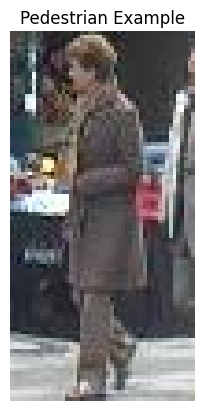

In [15]:
fig, ax = plt.subplots()
random_image_vector = train_ped[0]
plot_im(random_image_vector, ax=ax, title="Pedestrian Example")
plt.show()

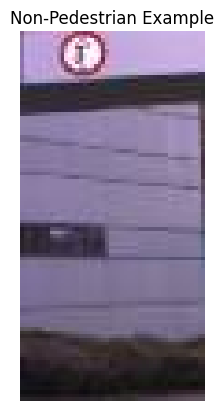

In [16]:
fig, ax = plt.subplots()
random_image_vector = train_no_ped[0]
plot_im(random_image_vector, ax=ax, title="Non-Pedestrian Example")
plt.show()

### Task 3.5 a

__Compute the PCA of the full training set for $q=200$__

In [17]:
from sklearn.decomposition import PCA

In [18]:
full_training_set = np.concatenate((train_ped_flat, train_no_ped_flat), axis=0)
full_train_classification = np.concatenate((np.ones(train_ped_flat.shape[0]), -np.ones(train_no_ped_flat.shape[0])), axis=0)

q=200
pca_solver = PCA(q)

# Note we work on flattened data as that gives the amount of dimensions to reduce
pca_solver.fit_transform(full_training_set)

array([[-3.08015193e+00,  7.71662866e+00, -3.43706593e+00, ...,
        -1.30918844e-02, -5.84395403e-01,  2.84147909e-01],
       [-5.33201086e+00,  1.36286131e+00, -3.96773880e+00, ...,
        -3.78208880e-01, -4.35752400e-01, -4.53150508e-01],
       [-8.75972456e+00,  1.29855589e+00,  2.82564781e+00, ...,
        -8.08373931e-02,  1.43107004e+00, -4.86297792e-01],
       ...,
       [ 2.05117551e+01, -4.00181056e+01,  3.91171215e+00, ...,
         1.49702011e+00, -1.61770463e-01,  3.92055664e-01],
       [ 1.81894130e+01,  7.91139969e+00, -5.95020138e+00, ...,
        -1.50767301e-01,  1.78422074e-01, -7.76519658e-03],
       [ 1.80239050e+00,  1.00497082e+01,  7.16967018e+00, ...,
         9.13864192e-01,  8.63530696e-03, -2.06642299e-01]])

### Task 3.5 b

__Plot the eigenpedestrian 1-20, 51-60, and 111-120__

In [19]:
# We import a helper function

from factor_split import split_factors_iterative, factor_based_split

In [20]:
def plot_principal_components(start_component, end_component):

    eigenpedestrians = pca_solver.components_[start_component-1:end_component]

    # We make a grid of images
    a, b = split_factors_iterative(end_component-start_component+1)
    fig, axes = plt.subplots(a, b, figsize=(10, 8))

    for i, ax in enumerate(axes.flat):

        # Get the i-th eigenpedestrian
        eigenpedestrian = eigenpedestrians[i]

        # Rescale the data to the [0, 1] range
        e_min = eigenpedestrian.min()
        e_max = eigenpedestrian.max()
        scaled_eigenpedestrian = (eigenpedestrian - e_min) / (e_max - e_min)

        # Plot this single eigenpedestrian on its designated axis
        plot_im(scaled_eigenpedestrian, ax=ax, title=f"Component {start_component + i}")

    plt.tight_layout()
    plt.show()

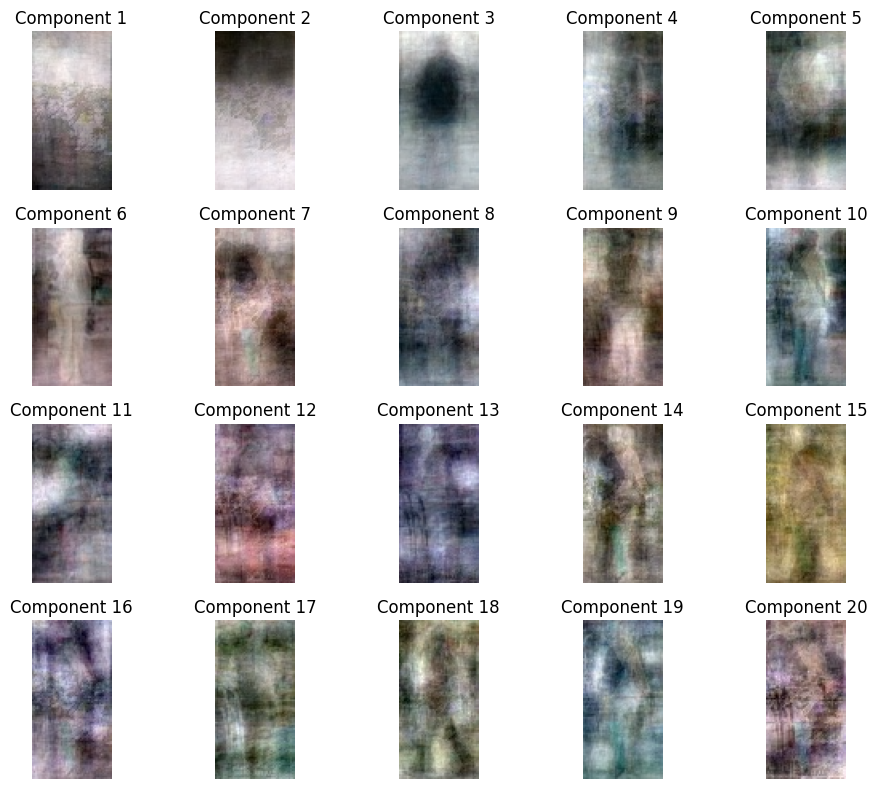

In [21]:
# Let's plot the first twenty eigenpedestrians

plot_principal_components(1, 20)

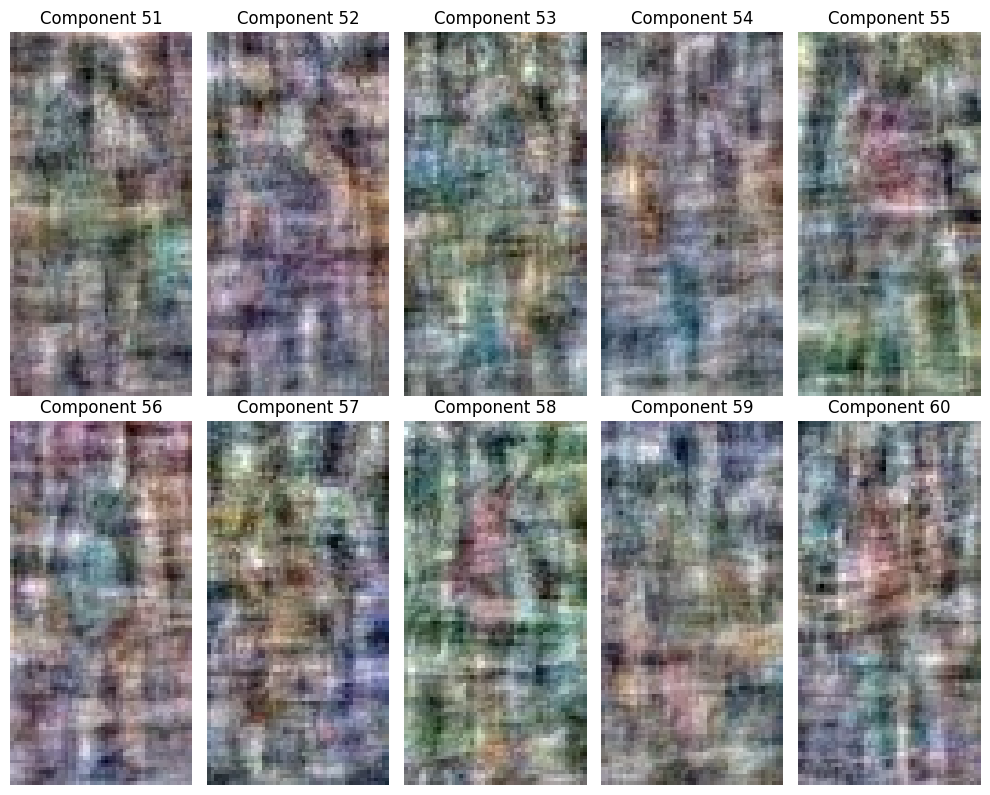

In [22]:
# Let's plot the 51-60 eigenpedestrians

plot_principal_components(51, 60)

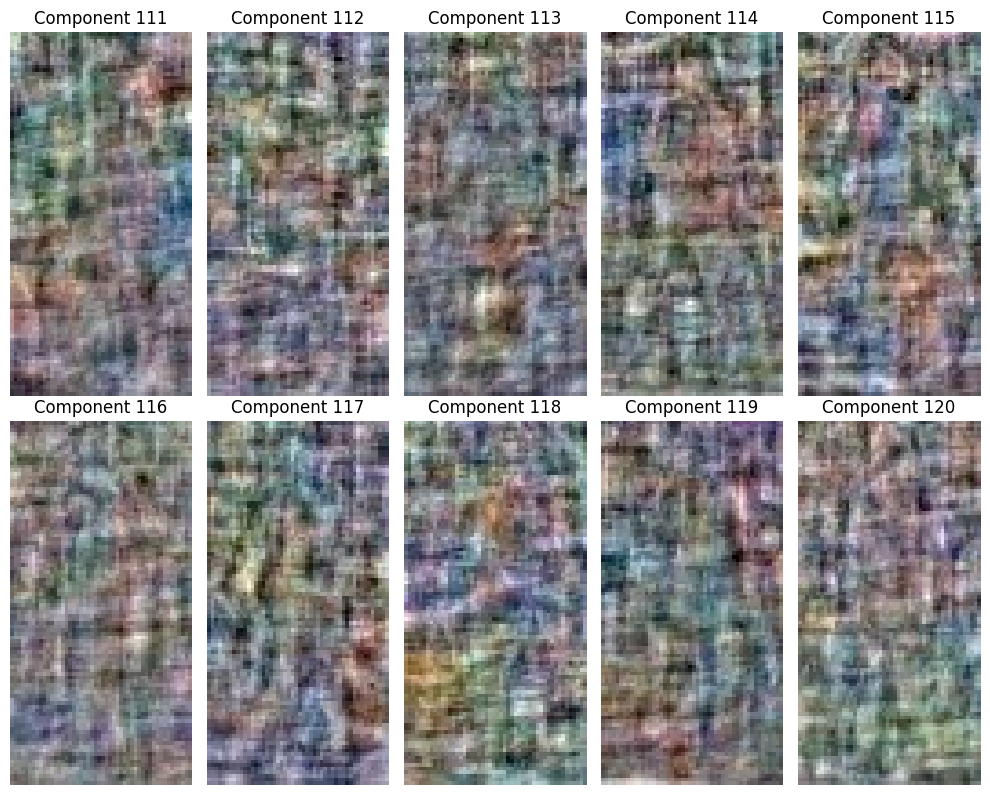

In [23]:
# Let's plot the 111-120 eigenpedestrians

plot_principal_components(111, 120)

### Task 3.6

__Compute the scores for a linear SVM using increasing numbers of principal components__

Use 10 to 200 components in steps of 5. Train the linear SVM with $C=0.01$ and increse the maximum number of iterations for the solver. You can reuse the computed PCA from above.

In [24]:
# Transform Test Data
full_test_set = np.concatenate((test_ped_flat, test_no_ped_flat), axis=0)
full_test_classification = np.concatenate((np.ones(test_ped_flat.shape[0]), -np.ones(test_no_ped_flat.shape[0])), axis=0)

transform_full_train_set = pca_solver.fit_transform(full_training_set)
transform_full_test_set = pca_solver.transform(full_test_set)

In [36]:
accuracy_score_over_q = [SVM_classifier(transform_full_train_set[:,:q], full_train_classification, transform_full_test_set[:,:q], full_test_classification)[1] for q in np.arange(10,201,5)]

Plot the training and test scores over $q$.

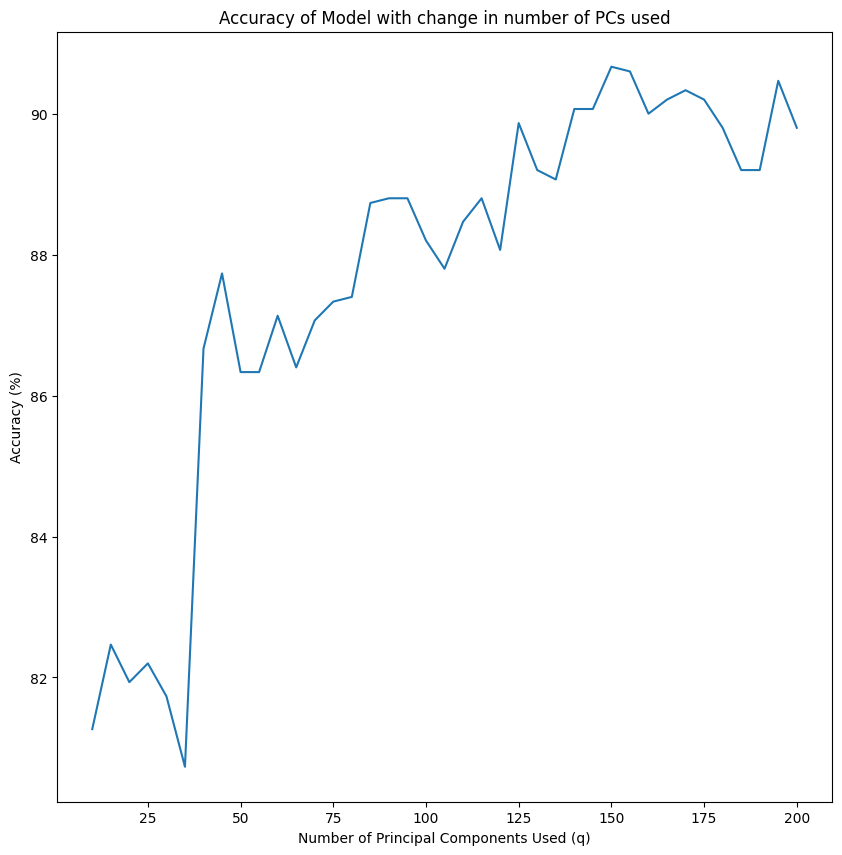

In [50]:
plt.figure(figsize=(10,10))
plt.plot(np.arange(10,201,5), np.array(accuracy_score_over_q)*100)
plt.xlabel("Number of Principal Components Used (q)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy of Model with change in number of PCs used")
plt.show()

### Task 3.7

## HOG Features

We decided to provide the implementation of the HOG features. (Task 3.7 a).

Bonus Task (only 3.7 b): Compute the HOG features of the test data. Then apply PCA and calculate the scores

In [38]:
import numpy as np
import scipy.ndimage as ndimage
from numpy.linalg import norm
from scipy.ndimage import convolve


class HogFeatures:
    def __init__(self, im_shape, n_bins=9, cell_size=8, blk_size=2, unsigned=True, clip_val=.2):
        self.deg_range = np.pi if unsigned else 2 * np.pi
        self.n_bins = n_bins
        self.bins = np.linspace(0, self.deg_range, n_bins, endpoint=False)
        self.bin_size = self.deg_range / n_bins
        self.cell_size = cell_size
        self.blk_size = blk_size
        self.clip_val = clip_val

        self.im_h, self.im_w = im_shape
        x, y = np.arange(self.im_w), np.arange(self.im_h)

        # Compute logical cell indices of next lower and upper cell
        # w.r.t. to the cell center
        cells_x = np.arange(-cell_size, self.im_w - (cell_size + 1)/2, cell_size)
        self.n_cells_x = len(cells_x) - (2 if cells_x[-1] >= self.im_w else 1)
        x0 = np.digitize(x, cells_x + cell_size / 2) - 2
        Xc = ((x0 + 1) - .5) * cell_size - .5
        f_x = (x - Xc) / cell_size

        cells_y = np.arange(-cell_size, self.im_h - (cell_size + 1)/2, cell_size)
        self.n_cells_y = len(cells_y) - (2 if cells_y[-1] >= self.im_h else 1)
        y0 = np.digitize(y, cells_y + cell_size / 2) - 2
        Yc = ((y0 + 1) - .5) * cell_size - .5
        f_y = (y - Yc) / cell_size

        self.f_x, self.f_y = np.meshgrid(f_x, f_y)

    def extract(self, im):
        """
        Extract the HOG features for a image.

        Parameters
        ----------

        im: ndarray
            An array of shape (height, width, 3).
        """
        im = np.rollaxis(im.reshape(self.im_h, self.im_w, -1), 2)
        dx = convolve(im, [[[1,0,-1]]], mode='constant')
        dy = convolve(im, [[[-1],[0],[1]]], mode='constant')
        grads_mag = norm(np.stack((dx, dy), axis=-1), axis=3)
        max_grads = np.argmax(np.rollaxis(grads_mag, 0, 3), 2)
        Y, X = np.ogrid[:grads_mag.shape[1], :grads_mag.shape[2]]
        grads_dir = np.arctan2(dy[max_grads, Y, X], dx[max_grads, Y, X]) % self.deg_range
        grads_mag = grads_mag[max_grads, Y, X]
        del dx, dy, max_grads, Y, X

        # Compute logical bin indices of next lower (<=) and upper bin (>)
        # w.r.t. to the bin center
        bin0 = np.digitize(grads_dir, self.bins + .5 * self.bin_size) - 1
        bin1 = bin0 + 1
        dirc = (bin0 + .5) * self.bin_size
        f_b = (grads_dir - dirc) / self.bin_size
        del grads_dir

        bin0 %= self.n_bins
        bin1 %= self.n_bins

        f_x, f_y = self.f_x, self.f_y

        hist = np.zeros((self.n_cells_y, self.n_cells_x, self.n_bins))
        bin_labels = np.arange(self.n_bins)
        # Iterate over all cells
        for ci_x in range(self.n_cells_x):
            x_pos = (ci_x * self.cell_size - (self.cell_size + 1) // 2, ci_x * self.cell_size + (self.cell_size + 1) // 2)
            x_pre = slice(max(0, x_pos[0] + self.cell_size), max(0, x_pos[1] + self.cell_size))
            x_pos = slice(max(0, x_pos[0]), x_pos[1])
            for ci_y in range(self.n_cells_y):
                y_pos = (ci_y * self.cell_size - (self.cell_size + 1) // 2, ci_y * self.cell_size + (self.cell_size + 1) // 2)
                y_pre = slice(max(0, y_pos[0] + self.cell_size), max(0, y_pos[1] + self.cell_size))
                y_pos = slice(max(0, y_pos[0]), y_pos[1])
                # Consider all four sourinding cells

                # y-pre x-pre
                m = (y_pre, x_pre)
                g = grads_mag[m] * (1 - f_x[m]) * (1 - f_y[m])
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)
                # y-pos x-pre
                m = (y_pos, x_pre)
                g = grads_mag[m] * (1 - f_x[m]) * f_y[m]
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)
                # y-pre x-pos
                m = (y_pre, x_pos)
                g = grads_mag[m] * f_x[m] * (1 - f_y[m])
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)
                # y-pos x-pos
                m = (y_pos, x_pos)
                g = grads_mag[m] * f_x[m] * f_y[m]
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)

        n_blks_x = self.n_cells_x + 1 - self.blk_size
        n_blks_y = self.n_cells_y + 1 - self.blk_size
        features = np.zeros((n_blks_x, n_blks_y, self.blk_size ** 2 * self.n_bins))
        for bi_x in range(n_blks_x):
            for bi_y in range(n_blks_y):
                blk = hist[bi_y:bi_y+self.blk_size, bi_x:bi_x+self.blk_size].copy()
                blk_norm = norm(blk.flatten())
                if blk_norm > 0:
                    blk /= blk_norm
                np.clip(blk, None, self.clip_val, out=blk)
                blk_norm = norm(blk.flatten())
                if blk_norm > 0:
                    blk /= blk_norm
                features[bi_x, bi_y] = blk.ravel()
        return features.flatten()


To test you Python implementation we provide some intermediate steps. The array `image` is the input, and `steps` contains the values of the inner variables of the HOG algorithm. The image is grayscale.

In [39]:
image, steps = mllab.pca.hog_test_data()

Number of bins: 9
Cell size: 8
Block size: 2
Unsigned directions: True
Clip value: 0.2


In [40]:
# Use Python implementation
hog = HogFeatures((100, 50))
print("Use Python implementation")

Use Python implementation


__Compute the HOG features for the training data, then compute the PCA for $q=200$.__

In [41]:
int_train_features = full_training_set

In [42]:
#! pip install tqdm
from tqdm import tqdm
hog_train_features = []
for i in tqdm(range(int_train_features.shape[0])):
    im = int_train_features[i].reshape(100, 50, 3)
    hog_train_features.append(hog.extract(im))
print("Computed HoG.")

100%|██████████| 2000/2000 [00:59<00:00, 33.74it/s]


Computed HoG.


PCA(n_components=200)

In [46]:
q = 200
hog_train_features = np.array(hog_train_features)
hog_train_pca = PCA(n_components=q)
hog_train_features_pca = hog_train_pca.fit_transform(hog_train_features)

__Compute and plot the scores as above, but this time use the HOG features.__

In [47]:
int_test_features = full_test_set

In [48]:
# compute hog features of test data
hog_test_features = []
for i in tqdm(range(int_test_features.shape[0])):
    im = int_test_features[i].reshape(100, 50, 3)
    hog_test_features.append(hog.extract(im))
print("Computed HoG.")

hog_test_features = np.array(hog_test_features)
hog_test_features_pca = hog_train_pca.transform(hog_test_features)

# compute scores

100%|██████████| 1500/1500 [00:41<00:00, 36.35it/s]

Computed HoG.


In [49]:
hog_accuracy_score_over_q = [SVM_classifier(hog_train_features_pca[:,:q], full_train_classification, hog_test_features_pca[:,:q], full_test_classification)[1] for q in np.arange(10,201,5)]

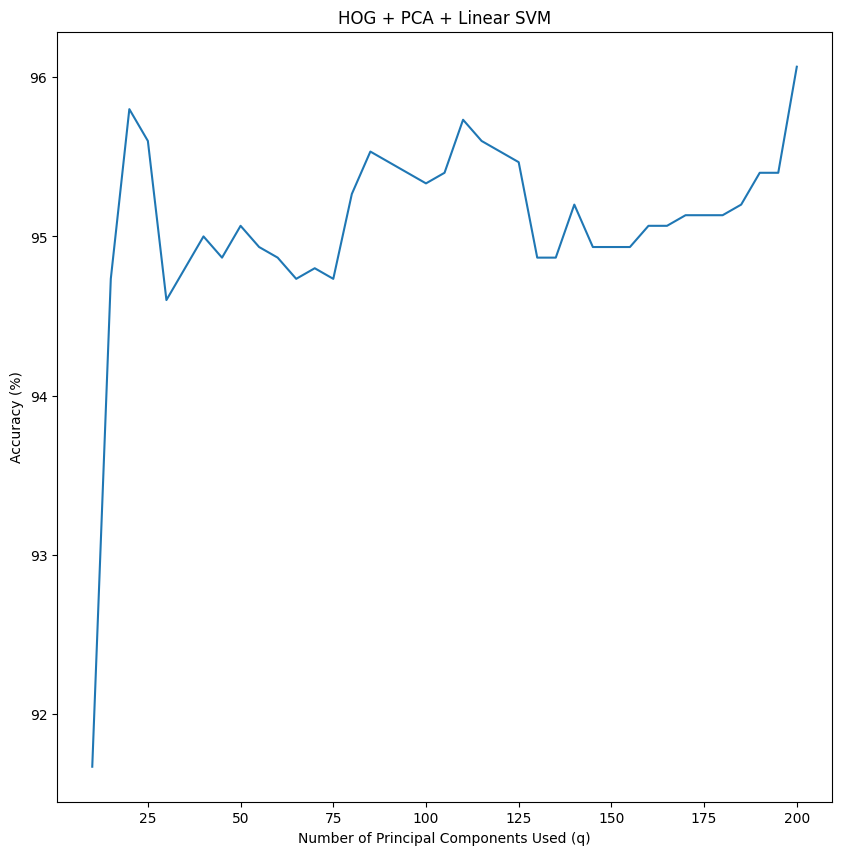

In [51]:
plt.figure(figsize=(10,10))
plt.title("HOG + PCA + Linear SVM")
plt.plot(np.arange(10,201,5), np.array(hog_accuracy_score_over_q)*100)
plt.xlabel("Number of Principal Components Used (q)")
plt.ylabel("Accuracy (%)")
plt.show()